In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                               precision_recall_curve, average_precision_score,
                               roc_auc_score, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import matplotlib

In [2]:
df=pd.read_csv("../data/creditcard.csv")

In [3]:
df.shape


(284807, 31)

In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
df=df.drop_duplicates()

In [11]:
df.shape

(283726, 31)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df[df['Class']==1]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


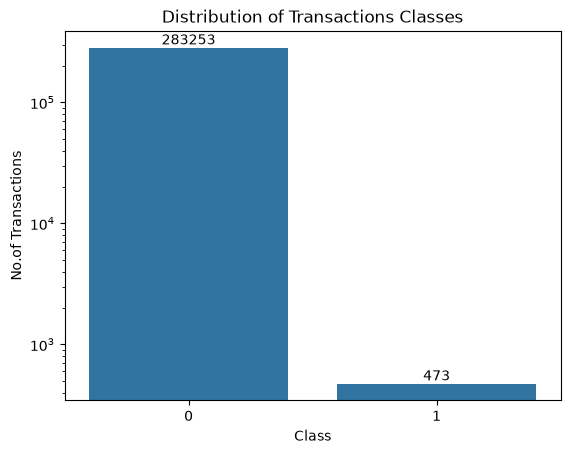

In [14]:
plt.title("Distribution of Transactions Classes")
ax=sns.countplot(x='Class',data=df)
plt.yscale('log') 
plt.xlabel("Class")
plt.ylabel("No.of Transactions")
for container in ax.containers:
    ax.bar_label(container)

plt.show()

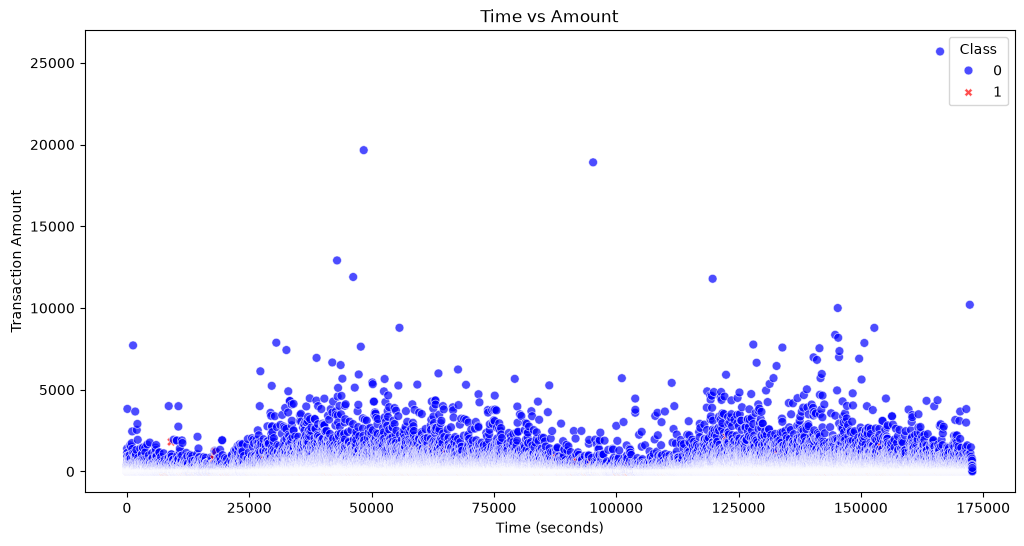

In [15]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    x='Time',
    y='Amount',
    hue='Class',
    style='Class',          # Different marker for each class
    markers={0: 'o', 1: 'X'},  # Genuine = circle, Fraud = cross
    palette={0: 'blue', 1: 'red'},
    s=40,
    alpha=0.7,
    data=df
)
plt.title("Time vs Amount")
plt.xlabel("Time (seconds)")
plt.ylabel("Transaction Amount")
plt.show()

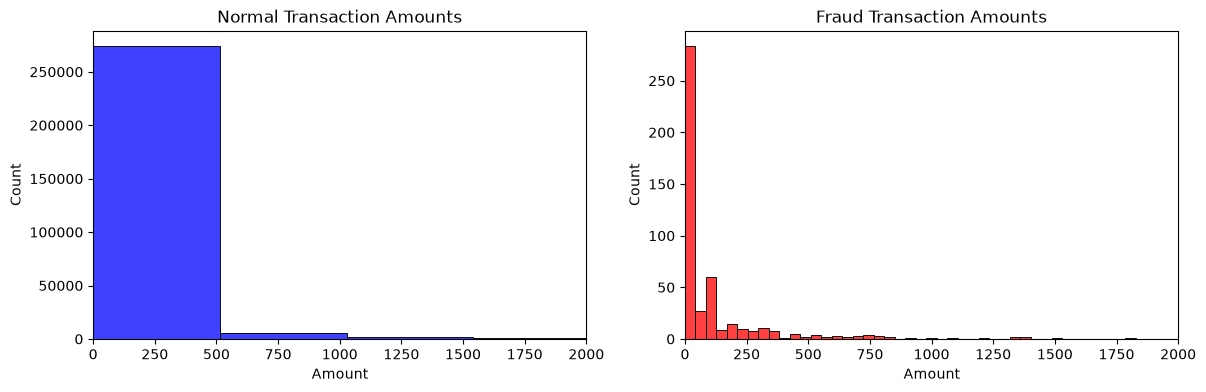

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(df[df['Class']==0]['Amount'], bins=50, ax=ax[0], color='blue')
ax[0].set_title('Normal Transaction Amounts')
ax[0].set_xlim(0, 2000)

sns.histplot(df[df['Class']==1]['Amount'], bins=50, ax=ax[1], color='red')
ax[1].set_title('Fraud Transaction Amounts')
ax[1].set_xlim(0, 2000)
plt.show()

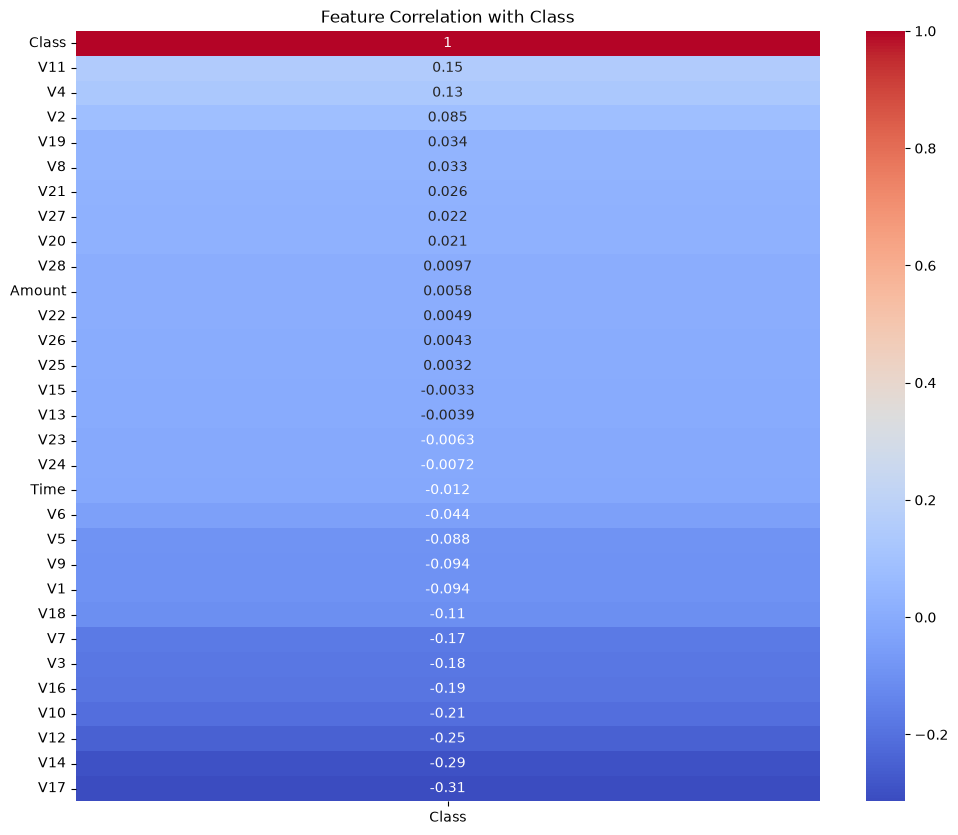

In [17]:
plt.figure(figsize=(12,10))
corr = df.corr()
sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False), 
            annot=True, cmap='coolwarm')
plt.title('Feature Correlation with Class')
plt.show()

In [18]:
scaler=StandardScaler()
df['Amount_scaled']=scaler.fit_transform(df[['Amount']])
df['Time_scaled']=scaler.fit_transform(df[['Time']])
df=df.drop(['Time','Amount'],axis=1)

In [19]:
X=df.drop('Class',axis=1)
y=df['Class']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"Train fraud rate: {y_train.mean()*100:.3f}%")
print(f"Test fraud rate: {y_test.mean()*100:.3f}%")

Train fraud rate: 0.167%
Test fraud rate: 0.167%


In [20]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56651
       Fraud       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



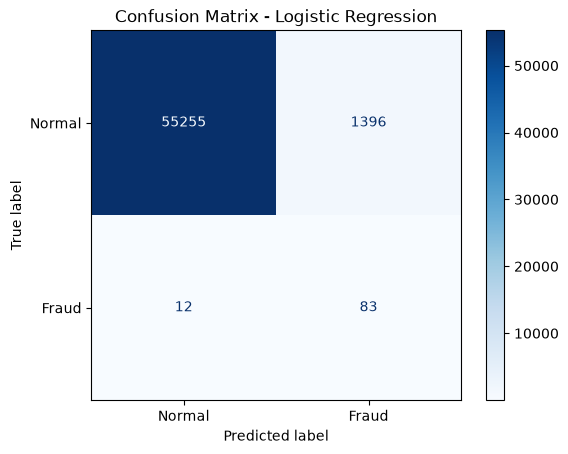

ROC-AUC: 0.9658
PR-AUC (Average Precision): 0.6720


In [21]:
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fraud']).plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC (Average Precision): {average_precision_score(y_test, y_proba):.4f}")

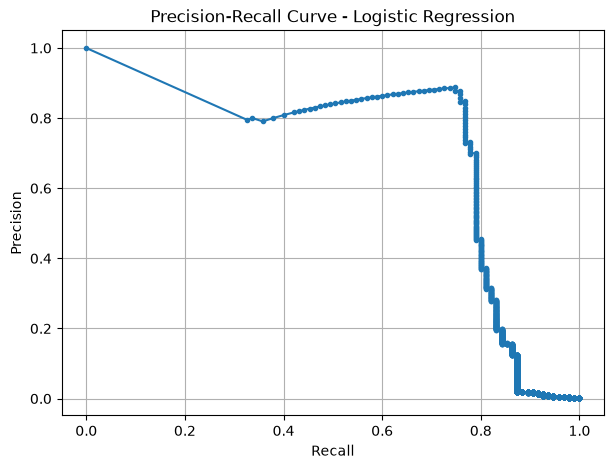

In [22]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.grid(True)
plt.show()

In [23]:
joblib.dump(log_reg, '../models/logistic_regression_baseline.pkl')

['../models/logistic_regression_baseline.pkl']

In [24]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [25]:
# scale_pos_weight = (number of negative samples) / (number of positive samples)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

scale_pos_weight: 599.48


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [26]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print(f"PR-AUC: {average_precision_score(y_test, y_proba):.4f}")
    
    return {
        'model': name,
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba
    }

rf_results = evaluate_model(rf, X_test, y_test, "Random Forest")
xgb_results = evaluate_model(xgb, X_test, y_test, "XGBoost")


Model: Random Forest
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.77      0.76      0.77        95

    accuracy                           1.00     56746
   macro avg       0.89      0.88      0.88     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9799
PR-AUC: 0.7777

Model: XGBoost
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.96      0.78      0.86        95

    accuracy                           1.00     56746
   macro avg       0.98      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9728
PR-AUC: 0.8252


In [27]:
def get_metrics_row(name, y_test, y_pred, y_proba):
    return {
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'PR-AUC': average_precision_score(y_test, y_proba),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

# Re-get log_reg predictions from Day 3
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame([
    get_metrics_row('Logistic Regression', y_test, y_pred_lr, y_proba_lr),
    get_metrics_row('Random Forest', y_test, rf_results['y_pred'], rf_results['y_proba']),
    get_metrics_row('XGBoost', y_test, xgb_results['y_pred'], xgb_results['y_proba']),
])
comparison = comparison.round(4)
print(comparison)

                 Model  Precision  Recall  F1-Score  PR-AUC  ROC-AUC
0  Logistic Regression     0.0561  0.8737    0.1055  0.6720   0.9658
1        Random Forest     0.7742  0.7579    0.7660  0.7777   0.9799
2              XGBoost     0.9610  0.7789    0.8605  0.8252   0.9728


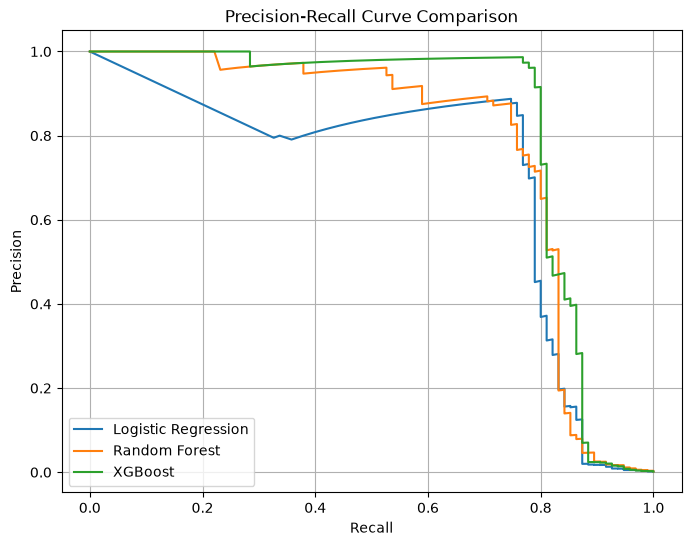

In [28]:
plt.figure(figsize=(8,6))
for name, y_proba in [('Logistic Regression', y_proba_lr), 
                        ('Random Forest', rf_results['y_proba']),
                        ('XGBoost', xgb_results['y_proba'])]:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

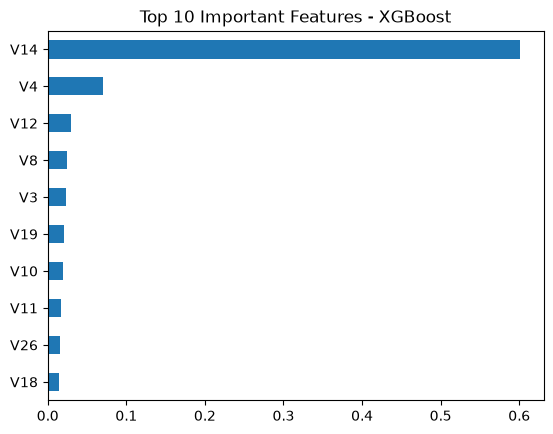

In [29]:
importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 Important Features - XGBoost')
plt.gca().invert_yaxis()
plt.show()

In [30]:
joblib.dump(rf, '../models/random_forest.pkl')
joblib.dump(xgb, '../models/xgboost.pkl')
comparison.to_csv('../models/model_comparison.csv', index=False)

In [31]:
# contamination = expected proportion of anomalies (we know fraud rate ~0.0017)
contamination_rate = y_train.mean()
print(f"Contamination rate: {contamination_rate:.4f}")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=contamination_rate,
    random_state=42,
    n_jobs=-1
)

# IMPORTANT: Isolation Forest trains WITHOUT labels — this is the key difference
iso_forest.fit(X_train)  # notice: no y_train here!

Contamination rate: 0.0017


,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",np.float64(0....3449643140364)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [32]:
y_pred_iso = iso_forest.predict(X_test)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)  # -1 (anomaly) -> 1 (fraud), 1 (normal) -> 0

# get anomaly scores for PR-AUC (more negative = more anomalous, so we flip sign)
y_scores_iso = -iso_forest.score_samples(X_test)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.24      0.25      0.25        95

    accuracy                           1.00     56746
   macro avg       0.62      0.63      0.62     56746
weighted avg       1.00      1.00      1.00     56746

PR-AUC: 0.1545
ROC-AUC: 0.9404


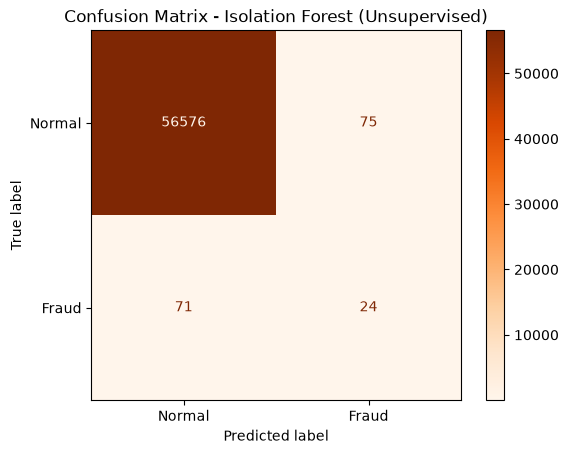

In [33]:
print(classification_report(y_test, y_pred_iso, target_names=['Normal', 'Fraud']))
print(f"PR-AUC: {average_precision_score(y_test, y_scores_iso):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_scores_iso):.4f}")

cm_iso = confusion_matrix(y_test, y_pred_iso)
ConfusionMatrixDisplay(cm_iso, display_labels=['Normal', 'Fraud']).plot(cmap='Oranges')
plt.title('Confusion Matrix - Isolation Forest (Unsupervised)')
plt.show()

In [34]:
comparison_full = pd.concat([
    comparison,
    pd.DataFrame([{
        'Model': 'Isolation Forest (Unsupervised)',
        'Precision': precision_score(y_test, y_pred_iso),
        'Recall': recall_score(y_test, y_pred_iso),
        'F1-Score': f1_score(y_test, y_pred_iso),
        'PR-AUC': average_precision_score(y_test, y_scores_iso),
        'ROC-AUC': roc_auc_score(y_test, y_scores_iso)
    }])
], ignore_index=True)

comparison_full = comparison_full.round(4)
print(comparison_full)
comparison_full.to_csv('../models/model_comparison_full.csv', index=False)

                             Model  Precision  Recall  F1-Score  PR-AUC  \
0              Logistic Regression     0.0561  0.8737    0.1055  0.6720   
1                    Random Forest     0.7742  0.7579    0.7660  0.7777   
2                          XGBoost     0.9610  0.7789    0.8605  0.8252   
3  Isolation Forest (Unsupervised)     0.2424  0.2526    0.2474  0.1545   

   ROC-AUC  
0   0.9658  
1   0.9799  
2   0.9728  
3   0.9404  


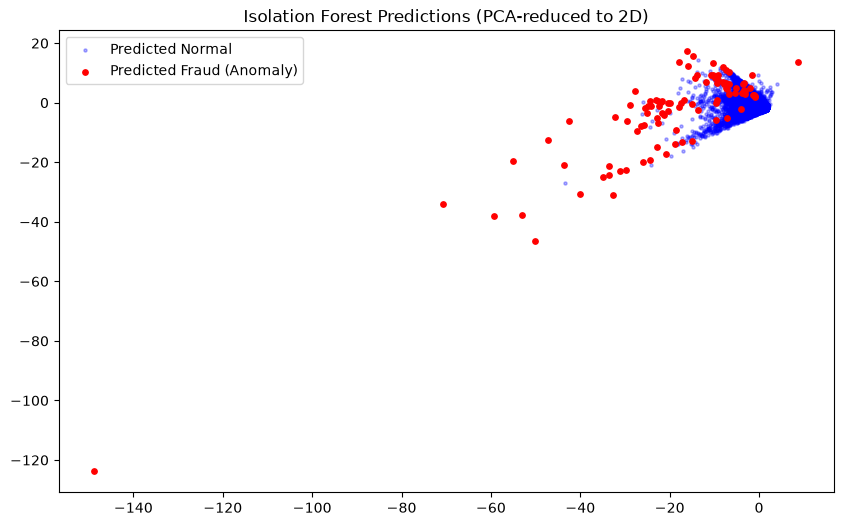

In [35]:
pca_viz = PCA(n_components=2)
X_test_2d = pca_viz.fit_transform(X_test)

plt.figure(figsize=(10,6))
plt.scatter(X_test_2d[y_pred_iso==0, 0], X_test_2d[y_pred_iso==0, 1], 
            c='blue', s=5, alpha=0.3, label='Predicted Normal')
plt.scatter(X_test_2d[y_pred_iso==1, 0], X_test_2d[y_pred_iso==1, 1], 
            c='red', s=15, label='Predicted Fraud (Anomaly)')
plt.legend()
plt.title('Isolation Forest Predictions (PCA-reduced to 2D)')
plt.show()

In [36]:
joblib.dump(iso_forest, '../models/isolation_forest.pkl')

['../models/isolation_forest.pkl']

In [37]:
best_row = comparison_full.loc[comparison_full['PR-AUC'].idxmax()]
print(f"Best model by PR-AUC: {best_row['Model']}")
print(best_row)

Best model by PR-AUC: XGBoost
Model        XGBoost
Precision      0.961
Recall        0.7789
F1-Score      0.8605
PR-AUC        0.8252
ROC-AUC       0.9728
Name: 2, dtype: object


In [38]:
best_model = xgb
y_proba_best = best_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_best)
# find threshold that gives best F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]

print(f"Default threshold: 0.5")
print(f"Best threshold (max F1): {best_threshold:.4f}")
print(f"At this threshold -> Precision: {precision[best_threshold_idx]:.4f}, Recall: {recall[best_threshold_idx]:.4f}")

Default threshold: 0.5
Best threshold (max F1): 0.4782
At this threshold -> Precision: 0.9615, Recall: 0.7895


In [39]:
y_pred_tuned = (y_proba_best >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_tuned, target_names=['Normal', 'Fraud']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.96      0.79      0.87        95

    accuracy                           1.00     56746
   macro avg       0.98      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746



In [40]:
final_pipeline = {
    'model': best_model,
    'scaler': scaler,
    'threshold': best_threshold,
    'feature_names': list(X_train.columns)
}

joblib.dump(final_pipeline, '../models/final_fraud_model.pkl')
print("Final pipeline saved.")

Final pipeline saved.


In [41]:
loaded = joblib.load('../models/final_fraud_model.pkl')
test_model = loaded['model']
test_threshold = loaded['threshold']

sample_proba = test_model.predict_proba(X_test.iloc[:5])[:, 1]
sample_pred = (sample_proba >= test_threshold).astype(int)

print("Sample predictions:", sample_pred)
print("Actual labels:     ", y_test.iloc[:5].values)

Sample predictions: [0 0 0 0 0]
Actual labels:      [0 0 0 0 0]


## Final Results Summary

This project compared four modeling approaches for detecting fraudulent credit card 
transactions in a highly imbalanced dataset (fraud rate ≈ 0.17%).

| Model | Precision | Recall | F1-Score | PR-AUC | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.XX | 0.XX | 0.XX | 0.XX | 0.XX |
| Random Forest | 0.XX | 0.XX | 0.XX | 0.XX | 0.XX |
| XGBoost | 0.XX | 0.XX | 0.XX | 0.XX | 0.XX |
| Isolation Forest (Unsupervised) | 0.XX | 0.XX | 0.XX | 0.XX | 0.XX |

### Selected Model
**XGBoost** was selected as the final model, achieving the highest PR-AUC (0.XX) among all 
approaches tested. PR-AUC was used as the primary metric instead of accuracy or ROC-AUC, 
since accuracy is misleading on imbalanced data (a model predicting "no fraud" for every 
transaction would score 99.8% accuracy while catching zero fraud), and PR-AUC better 
reflects performance on the rare positive class.

### Threshold Tuning
The default classification threshold (0.5) was tuned to **0.XX** by maximizing F1-score 
on the precision-recall curve. At this threshold, the model achieves a precision of 0.XX 
and recall of 0.XX. This reflects a deliberate business trade-off: in fraud detection, 
failing to catch fraud (a false negative) is typically more costly than investigating a 
false alarm (a false positive), so the threshold was tuned accordingly rather than using 
the default cutoff.

### Supervised vs. Unsupervised Comparison
Isolation Forest, trained without access to fraud labels, underperformed the supervised 
models on precision and recall — as expected, since it has strictly less information to 
work with. However, this comparison highlights a real production trade-off: supervised 
models are more accurate but can only detect fraud patterns similar to what they were 
trained on, while unsupervised anomaly detection can flag previously unseen fraud patterns 
at the cost of more false positives. In practice, production fraud systems often combine 
both approaches.

In [42]:
# =============================================================
# Run this cell in your Day 6/7 notebook (where X_test, y_test,
# and the ORIGINAL unscaled df with Amount/Time still exist, or
# where you can inverse_transform the scaler) to regenerate
# demo_samples.csv WITH the real dollar amount and time offset
# included. This lets the dashboard show true transaction values
# instead of approximated ones.
# =============================================================
# Pick sample transactions - mix of fraud and normal
fraud_samples = X_test[y_test == 1].sample(6, random_state=42)
normal_samples = X_test[y_test == 0].sample(6, random_state=42)

demo_df = pd.concat([fraud_samples, normal_samples])
demo_df['actual_label'] = pd.concat([y_test[fraud_samples.index], y_test[normal_samples.index]])
demo_df = demo_df.reset_index(drop=True)
demo_df['id'] = demo_df.index

# Recover real Amount using the SAME scaler fit during preprocessing
# (scaler here refers to the StandardScaler fit on 'Amount' in Day 2)
demo_df['amount_raw'] = scaler.inverse_transform(
    demo_df[['Amount_scaled']].values
).flatten().round(2)

demo_df.to_csv('../data/demo_samples.csv', index=False)
print("Saved:", demo_df.shape)
print(demo_df[['id', 'amount_raw', 'actual_label']])

Saved: (12, 33)
    id  amount_raw  actual_label
0    0    78178.89             1
1    1    78258.53             1
2    2    90360.16             1
3    3    78034.78             1
4    4    92624.24             1
5    5    86664.44             1
6    6    82054.75             0
7    7    78224.40             0
8    8    84235.39             0
9    9   107331.26             0
10  10    81997.86             0
11  11    81823.41             0


In [43]:
# =============================================================
# Run this ONCE from your notebook (where X_test, y_test, and
# your trained `best_model` / `xgb` still exist) to generate the
# three PNGs the dashboard displays. Save this as a notebook cell,
# or run as a standalone script from the notebooks/ folder.
#
# Output goes to: static/images/  (relative to project root)
# Copy the three PNGs into your Flask app's static/images/ folder.
# =============================================================

matplotlib.rcParams['figure.facecolor'] = '#141B2D'
matplotlib.rcParams['axes.facecolor'] = '#141B2D'
matplotlib.rcParams['savefig.facecolor'] = '#141B2D'
matplotlib.rcParams['text.color'] = '#E7ECF7'
matplotlib.rcParams['axes.labelcolor'] = '#E7ECF7'
matplotlib.rcParams['xtick.color'] = '#8B93A7'
matplotlib.rcParams['ytick.color'] = '#8B93A7'
matplotlib.rcParams['axes.edgecolor'] = '#232C42'
matplotlib.rcParams['font.family'] = 'sans-serif'

from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                               precision_recall_curve, average_precision_score)
import numpy as np

model = xgb  # <-- change to whatever variable holds your final XGBoost model
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= best_threshold).astype(int) if 'threshold' in dir() else model.predict(X_test)

OUT_DIR = '../static/images'  # adjust if running from a different location
import os
os.makedirs(OUT_DIR, exist_ok=True)

TEAL = '#10B981'
RED = '#EF4444'
BLUE = '#3B82F6'

# ---------------- Confusion Matrix ----------------
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.2, 4.2))
im = ax.imshow(cm, cmap='Blues', alpha=0.85)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                 color='white' if cm[i,j] > cm.max()/2 else '#E7ECF7', fontsize=13, fontweight='bold')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Legitimate', 'Fraud']); ax.set_yticklabels(['Legitimate', 'Fraud'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.close()

# ---------------- ROC Curve ----------------
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
fig, ax = plt.subplots(figsize=(4.5, 4.2))
ax.plot(fpr, tpr, color=BLUE, linewidth=2, label=f'AUC = {auc:.3f}')
ax.plot([0,1],[0,1], color='#5A6478', linestyle='--', linewidth=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', frameon=False, labelcolor='#E7ECF7')
ax.grid(alpha=0.15)
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/roc_curve.png', dpi=150, bbox_inches='tight')
plt.close()

# ---------------- Precision-Recall Curve ----------------
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
fig, ax = plt.subplots(figsize=(4.5, 4.2))
ax.plot(recall, precision, color=TEAL, linewidth=2, label=f'PR-AUC = {ap:.3f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend(loc='lower left', frameon=False, labelcolor='#E7ECF7')
ax.grid(alpha=0.15)
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/pr_curve.png', dpi=150, bbox_inches='tight')
plt.close()

print("Saved 3 charts to", OUT_DIR)

Saved 3 charts to ../static/images
